In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Read file

In [3]:
df = pd.read_csv('train1.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


2. Vizualiation 

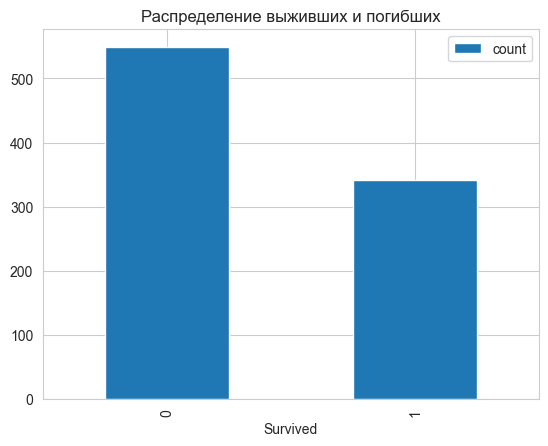

In [14]:
df['Survived'].value_counts().plot(kind='bar', legend='True', title='Распределение выживших и погибших');

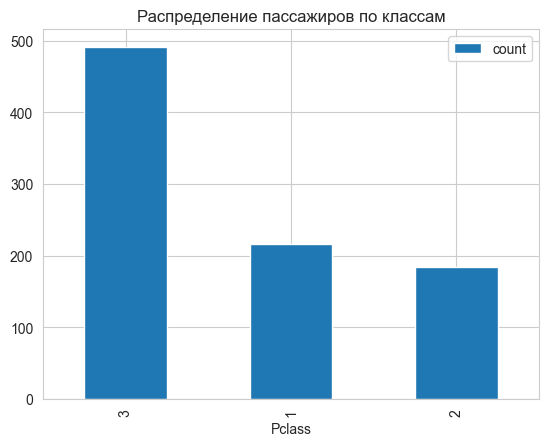

In [15]:
df['Pclass'].value_counts().plot(kind='bar', legend='True', title='Распределение пассажиров по классам');

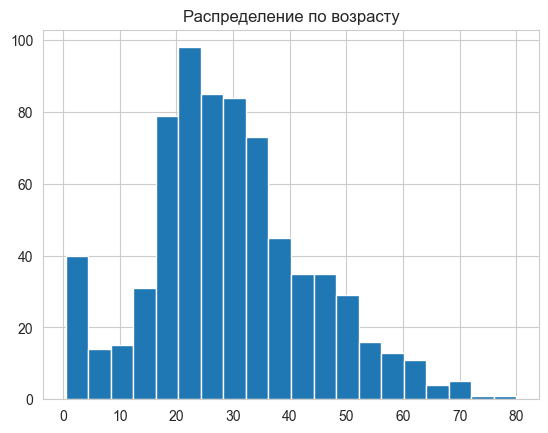

In [23]:
df['Age'].hist(bins=20);
plt.title('Распределение по возрасту')
plt.show()

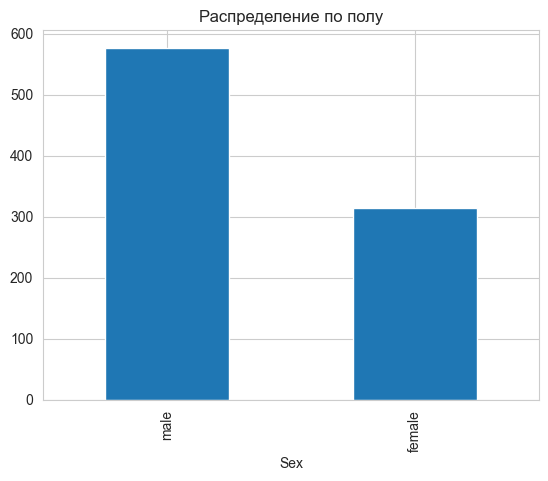

In [24]:
df['Sex'].value_counts().plot(kind='bar')
plt.title('Распределение по полу')
plt.show()

<Axes: xlabel='Parch'>

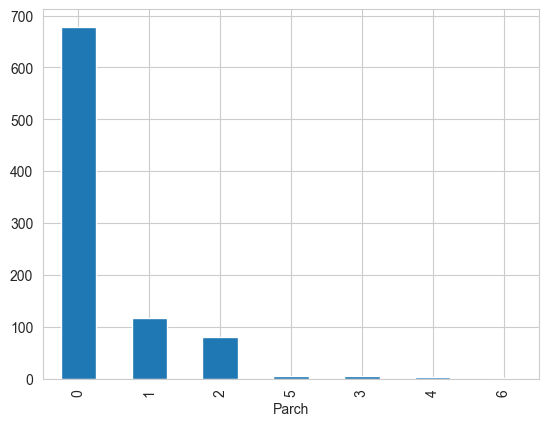

In [11]:
df['Parch'].value_counts().plot(kind='bar')

3. Boxplot for age 

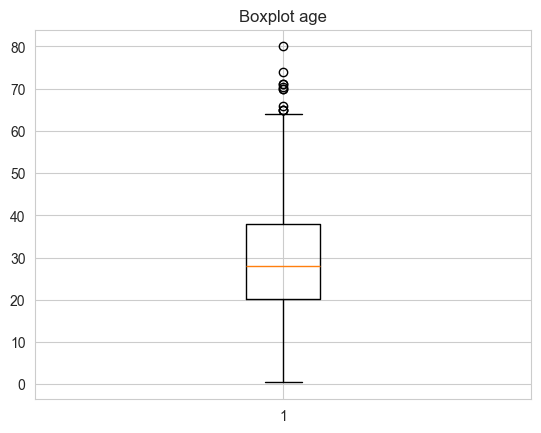

In [26]:
plt.boxplot(df['Age'].dropna())
plt.title('Boxplot age');

Медиана около 27 лет, большинство пассажиров в диапазоне 20–40 лет

4. Pie chart for  Survived, Pclass

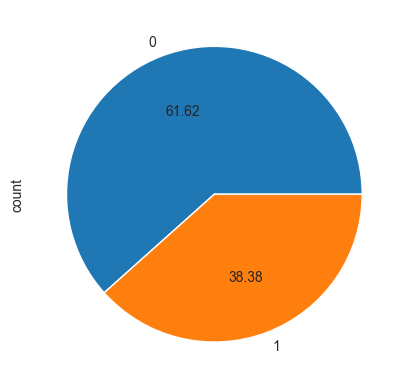

In [21]:
df['Survived'].value_counts().plot(kind='pie', autopct='%1.2f');

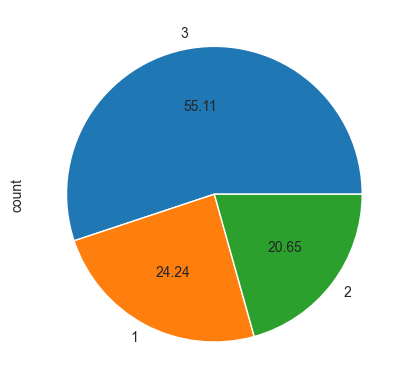

In [23]:
df['Pclass'].value_counts().plot(kind='pie', autopct='%1.2f');

Pairplot for int

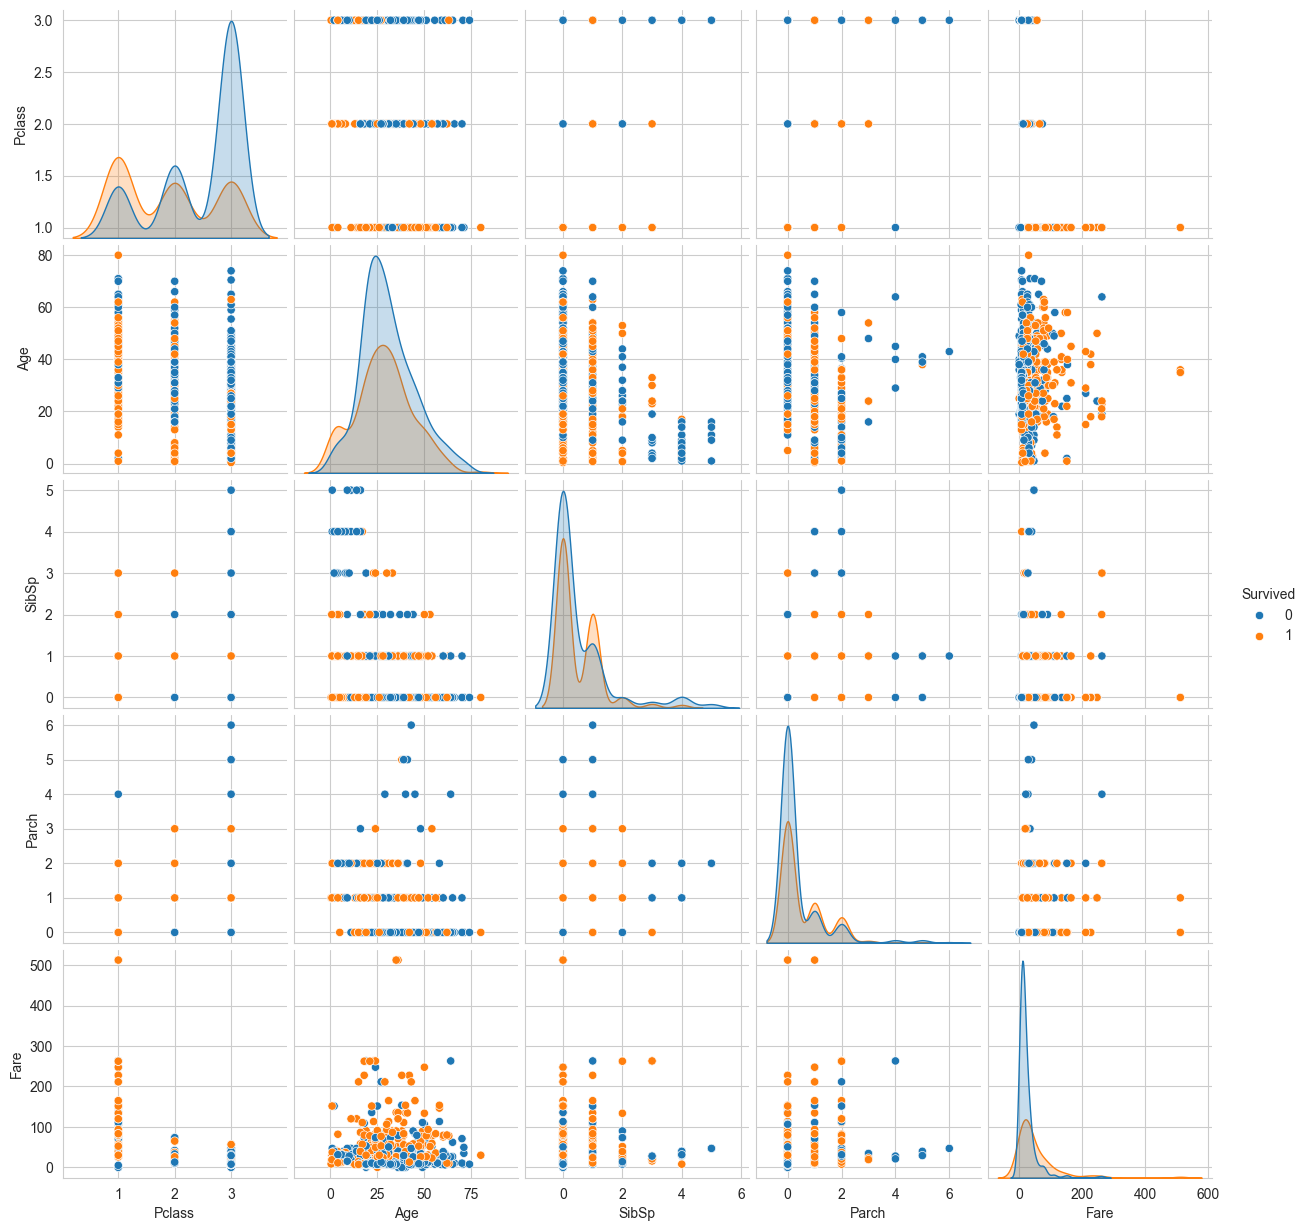

In [28]:
sns.pairplot(df[["Survived","Pclass","Age","SibSp","Parch","Fare"]].dropna(), hue='Survived');

sunburst plot

In [37]:
total = len(df)
total

891

In [39]:
class_counts = df["Pclass"].value_counts().sort_index()
class_counts

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [41]:
sex_counts = df.groupby(["Pclass", "Sex"]).size()
sex_counts

Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      347
dtype: int64

In [6]:
data = dict(
categories = ["Total", "1", "2", "3", 
              "male", "female",
              "male", "female",
              "male", "female"],
parent = ["", "Total", "Total", "Total",
          "1", "1",
          "2", "2",
          "3", "3"],
value = [891, 216, 184, 491,
         122, 94, 
         108, 76, 
         347, 144])
fig = px.sunburst(data, names = 'categories', parents='parent', values = 'value', branchvalues='total')
fig.show()
